In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("House_Prices.csv")
print(df.info())
print(df.describe())

num = df.select_dtypes(include = np.number)
cat = df.select_dtypes(exclude = np.number)

df[num.columns] = num.fillna(num.median())
df[cat.columns] = cat.fillna(cat.mode().iloc[0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
df['TotalArea'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['TotalBathrooms'] = df['FullBath'] + 0.5 * df['HalfBath']
df['PricePerSqft'] = df['SalePrice'] / df['GrLivArea']

print(df.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave  Grvl      Reg   
1   2          20       RL         80.0     9600   Pave  Grvl      Reg   
2   3          60       RL         68.0    11250   Pave  Grvl      IR1   
3   4          70       RL         60.0     9550   Pave  Grvl      IR1   
4   5          60       RL         84.0    14260   Pave  Grvl      IR1   

  LandContour Utilities  ... MiscVal MoSold YrSold SaleType SaleCondition  \
0         Lvl    AllPub  ...       0      2   2008       WD        Normal   
1         Lvl    AllPub  ...       0      5   2007       WD        Normal   
2         Lvl    AllPub  ...       0      9   2008       WD        Normal   
3         Lvl    AllPub  ...       0      2   2006       WD       Abnorml   
4         Lvl    AllPub  ...       0     12   2008       WD        Normal   

  SalePrice TotalArea  HouseAge  TotalBathrooms  PricePerSqft  
0    208500      2566       

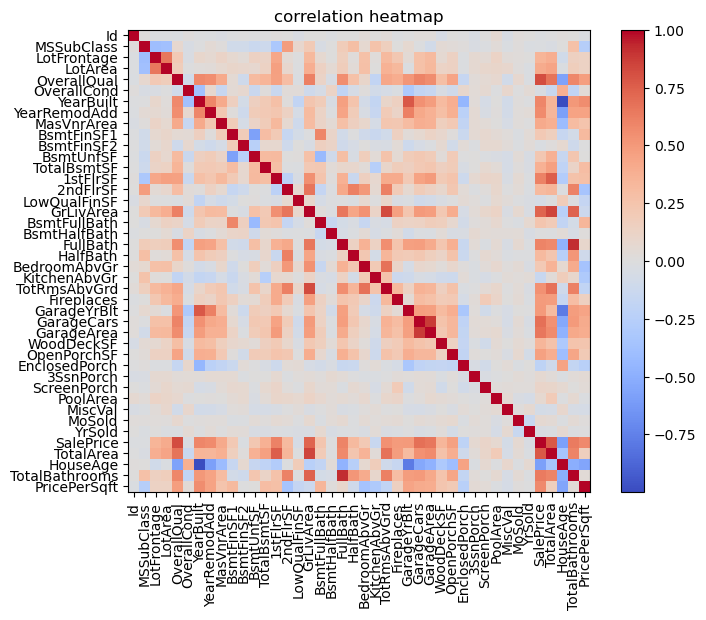

OverallQual    0.817185
TotalArea      0.777297
GrLivArea      0.730254
GarageCars     0.680625
GarageArea     0.650888
Name: SalePrice, dtype: float64
Id                0.000000
MSSubClass        0.248997
LotFrontage      -0.870006
LotArea          -0.137404
OverallQual       0.216944
OverallCond       0.693067
YearBuilt        -0.613461
YearRemodAdd     -0.503562
MasVnrArea        0.503532
BsmtFinSF1       -0.618410
BsmtFinSF2        2.523694
BsmtUnfSF         0.920268
TotalBsmtSF      -5.154670
1stFlrSF          0.080114
2ndFlrSF          0.813030
LowQualFinSF      7.460317
GrLivArea        -0.006140
BsmtFullBath      0.596067
BsmtHalfBath      3.933064
FullBath          0.036562
HalfBath          0.675897
BedroomAbvGr      0.211790
KitchenAbvGr      3.869414
TotRmsAbvGrd      0.676341
Fireplaces        0.649565
GarageYrBlt      -0.678333
GarageCars       -0.342549
GarageArea        0.179981
WoodDeckSF        0.153537
OpenPorchSF      -0.023397
EnclosedPorch     2.112275
3SsnPorch  

<ipython-input-21-2643d8a3b485>:20: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.skewed = np.log1p(df[skewed])


after:
 BsmtFinSF2        2.523694
LowQualFinSF      7.460317
BsmtHalfBath      3.933064
KitchenAbvGr      3.869414
EnclosedPorch     2.112275
3SsnPorch         7.734975
ScreenPorch       3.150409
PoolArea         14.363102
MiscVal           5.170704
dtype: float64


In [21]:
import matplotlib.pyplot as plt
import numpy as np

corr = df.select_dtypes(include = np.number).corr()

plt.figure(figsize = (8,6))
plt.imshow(corr, cmap = 'coolwarm')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("correlation heatmap")
plt.show()

print(corr['SalePrice'].sort_values(ascending=False)[1:6])

skew = df[num.columns].skew()
print(skew)

skewed = skew[skew>1].index
df.skewed = np.log1p(df[skewed])
print("after:\n", df[skewed].skew())